<a href="https://colab.research.google.com/github/MiguelAngeloTr/Aprendizaje_Automatico/blob/main/SEMANA_6/TAREA_5/MODELO_2_3_COMPONENTES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**EDA**

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Path to dataset files: /kaggle/input/breast-cancer-wisconsin-data


In [2]:

import pandas as pd


diagnostic=pd.read_csv(path+"/data.csv")
diagnostic.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
print(diagnostic.columns)

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')


In [4]:
#Eliminar columnas inecesarias

diagnostic= diagnostic.drop(columns=['id','Unnamed: 32'], axis=1)

In [5]:
diagnostic.shape

(569, 31)

Valores nulos

In [6]:
diagnostic.isna().any().any()



np.False_

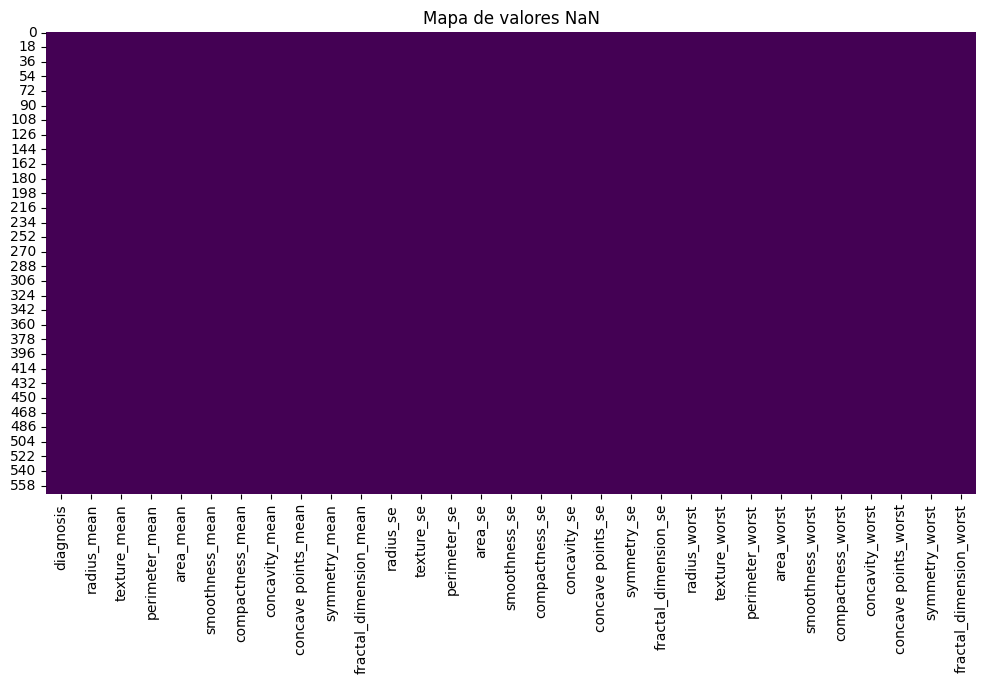

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(diagnostic.isna(), cbar=False, cmap='viridis')
plt.title("Mapa de valores NaN")
plt.show()


In [8]:
diagnostic['diagnosis'].value_counts().to_frame()


,count
diagnosis,
B,357
M,212


In [9]:
import seaborn as sns
#Muchas caracteristicas

#sns.pairplot(diagnostic, hue="diagnosis", markers=["o", "s"], palette="Set2")

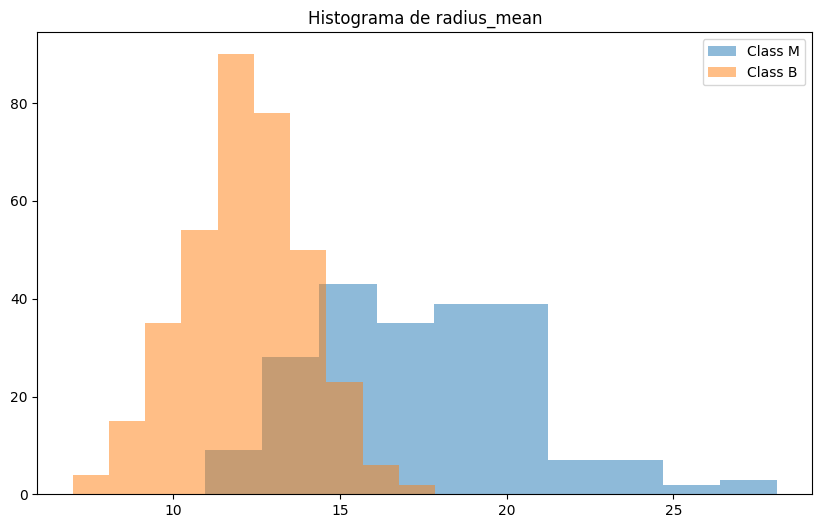

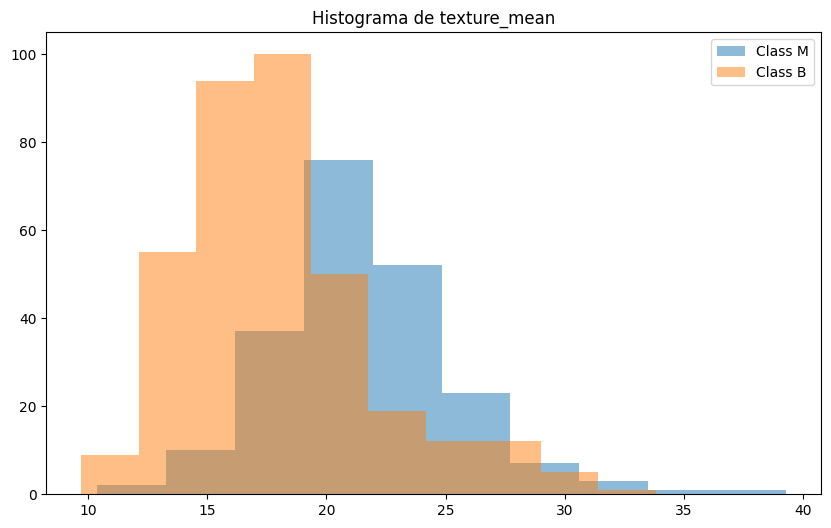

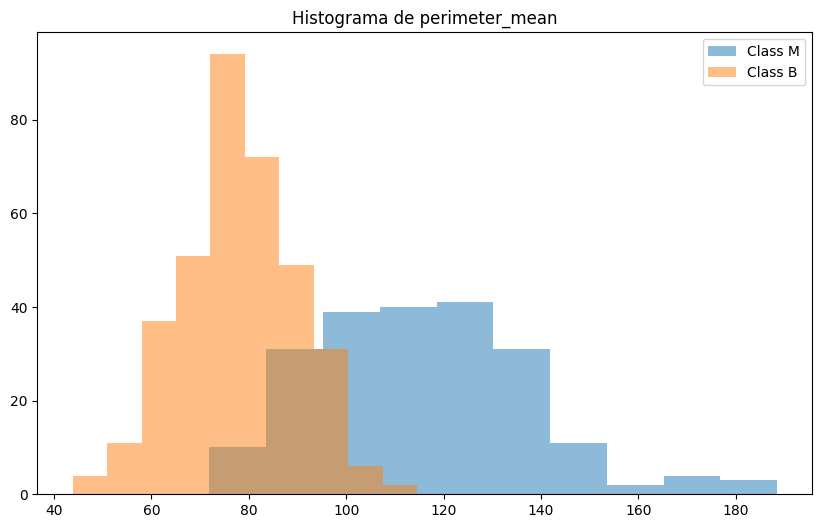

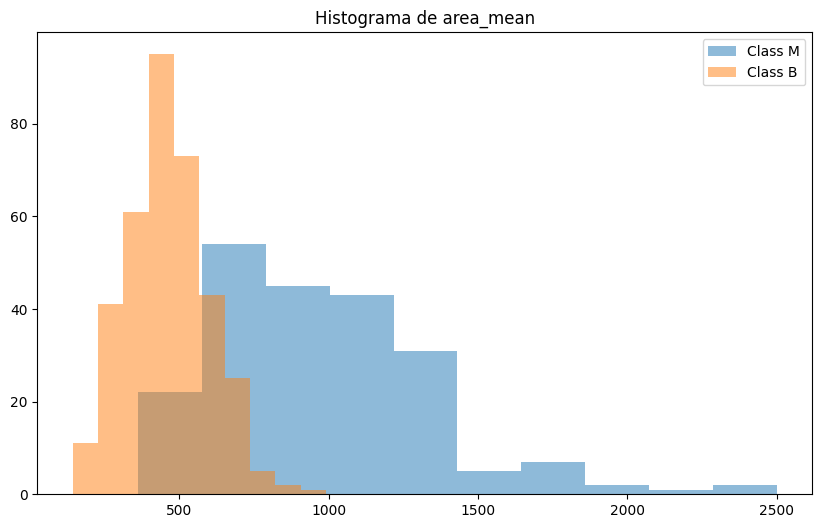

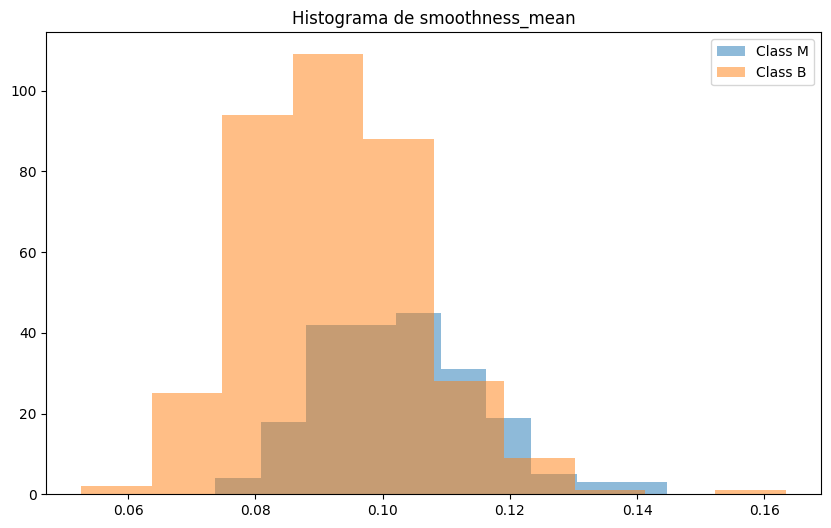

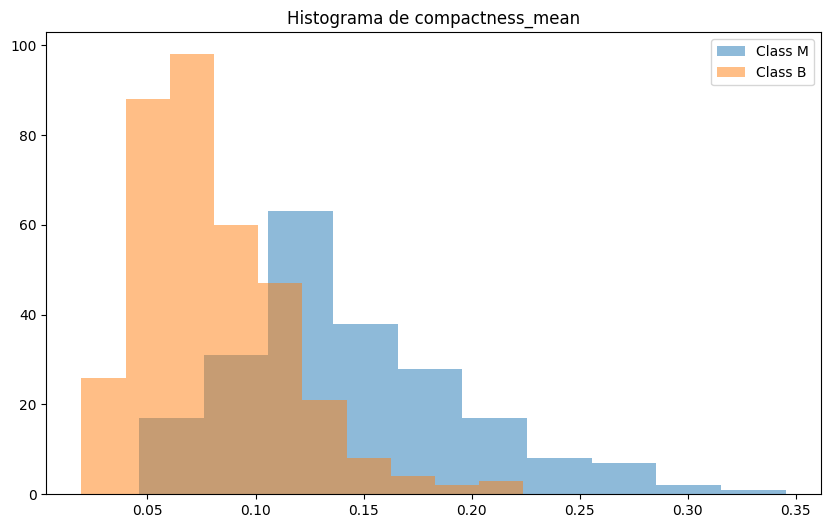

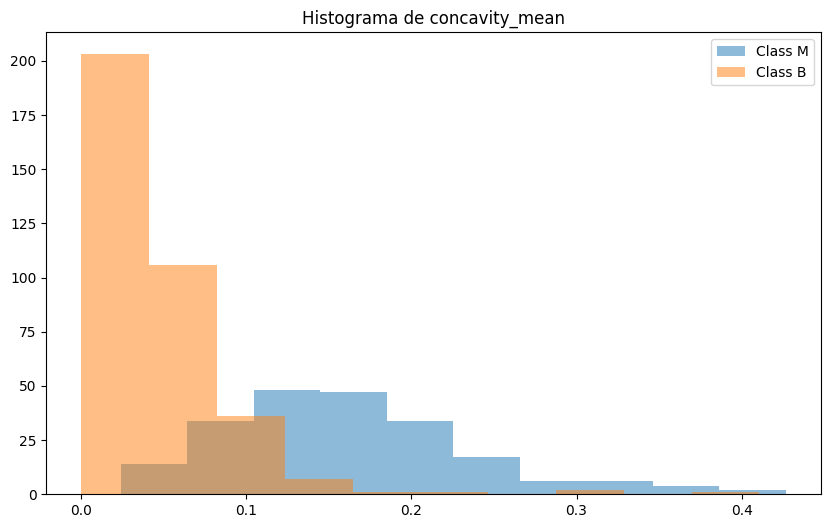

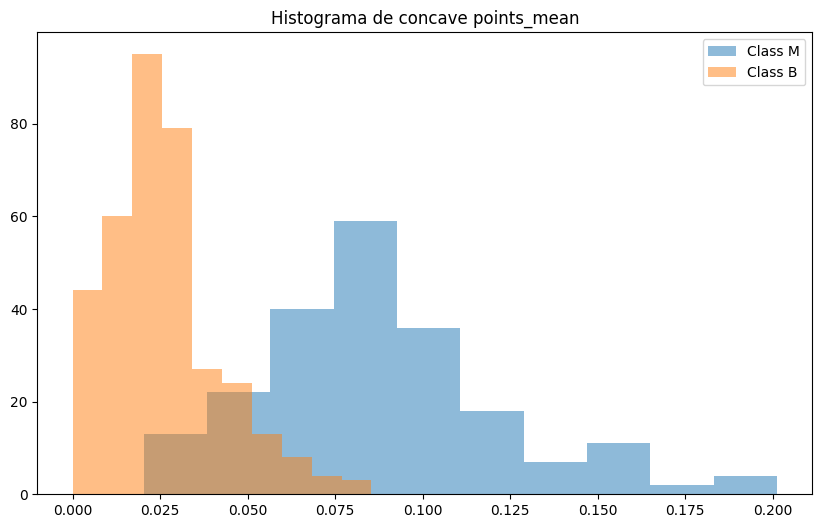

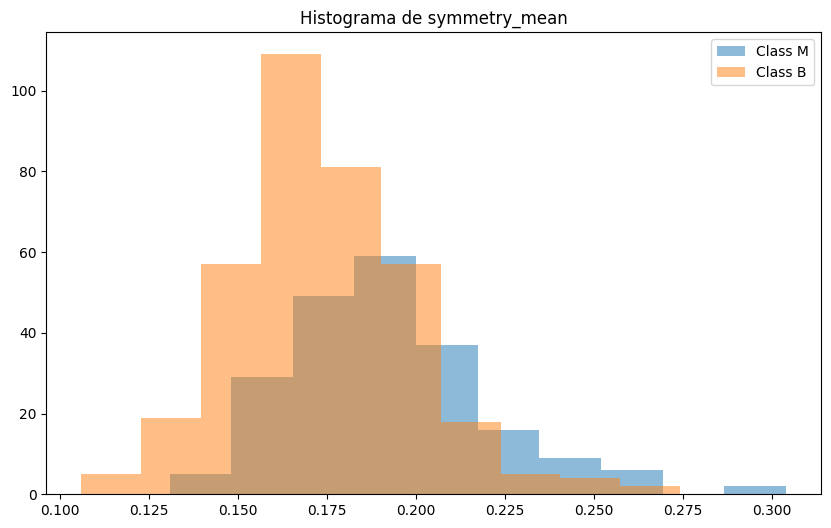

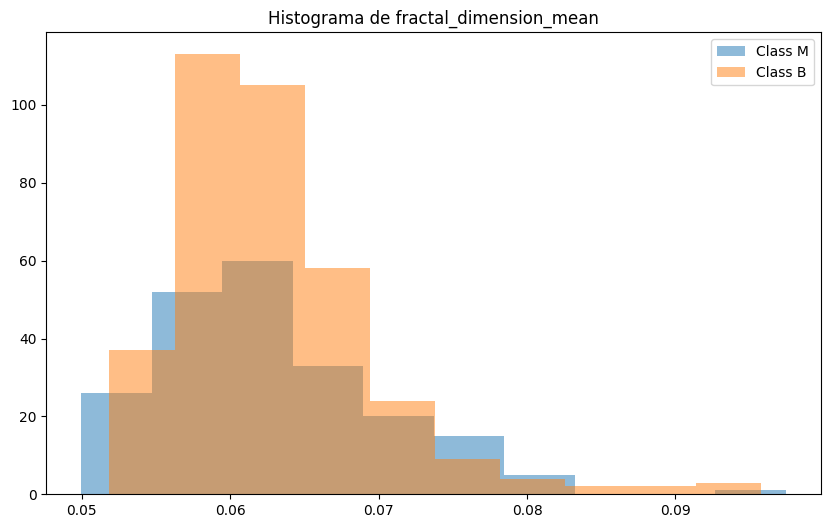

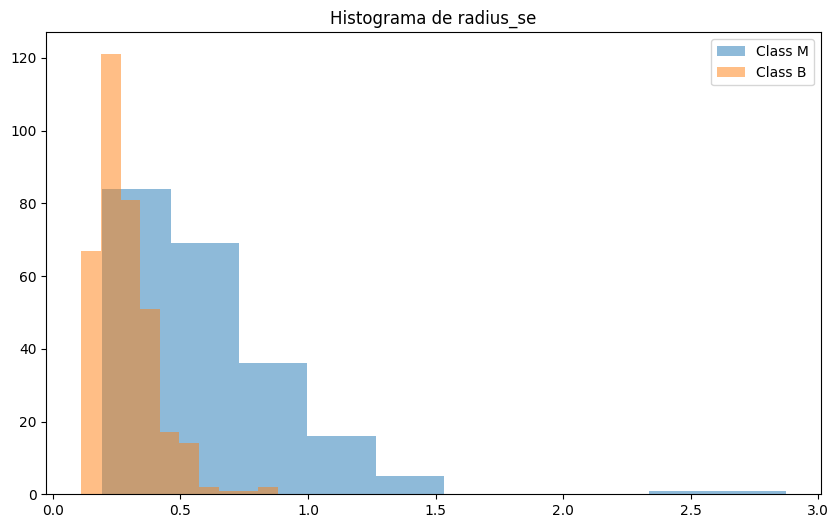

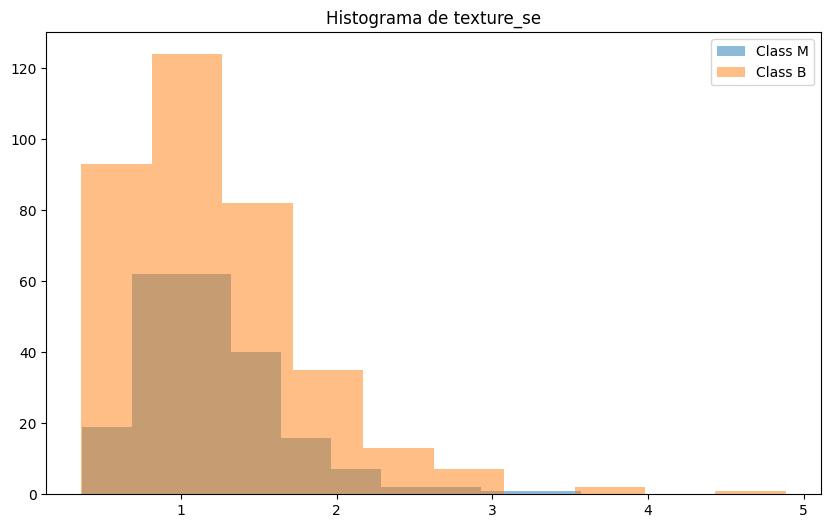

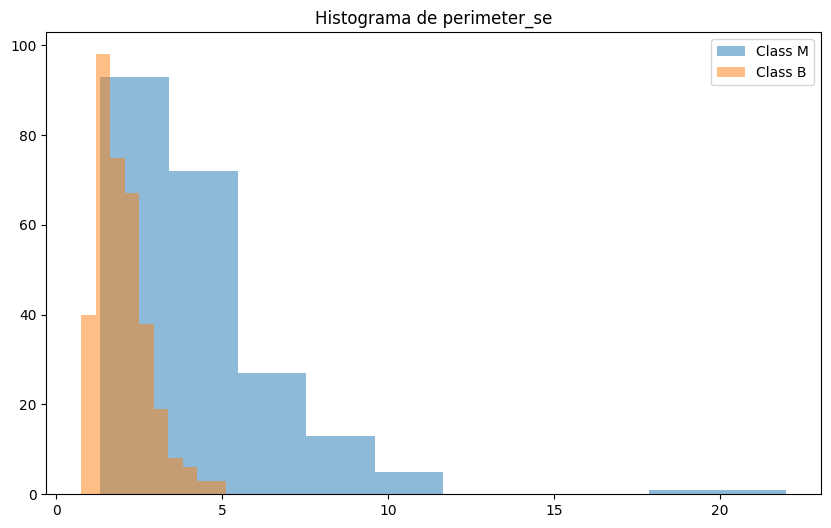

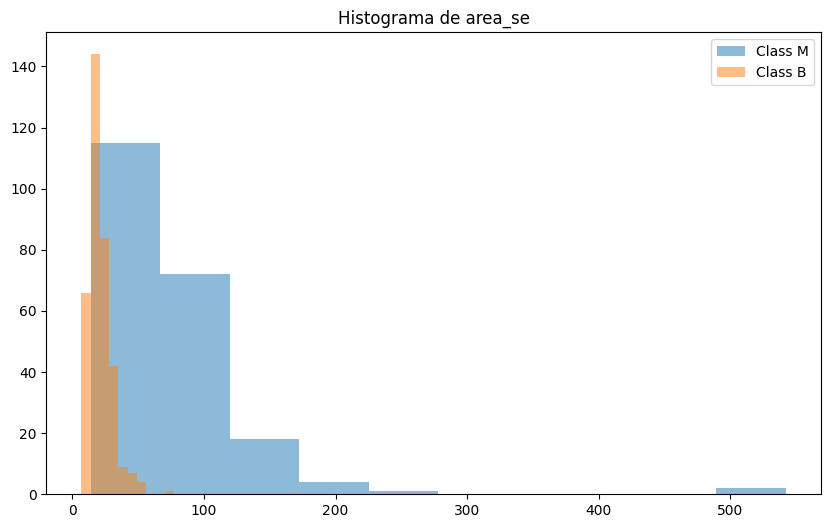

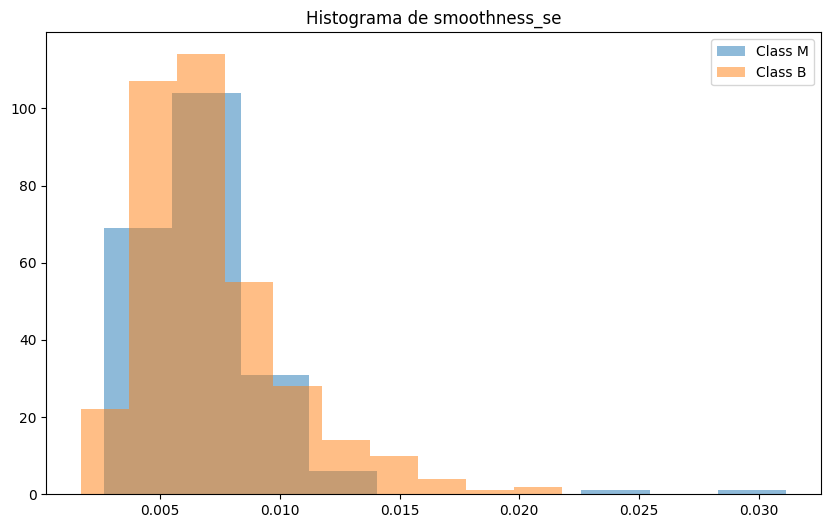

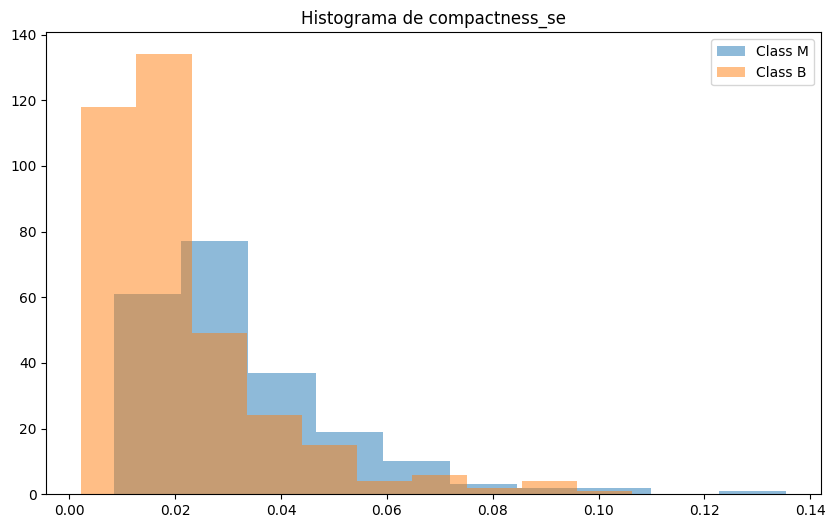

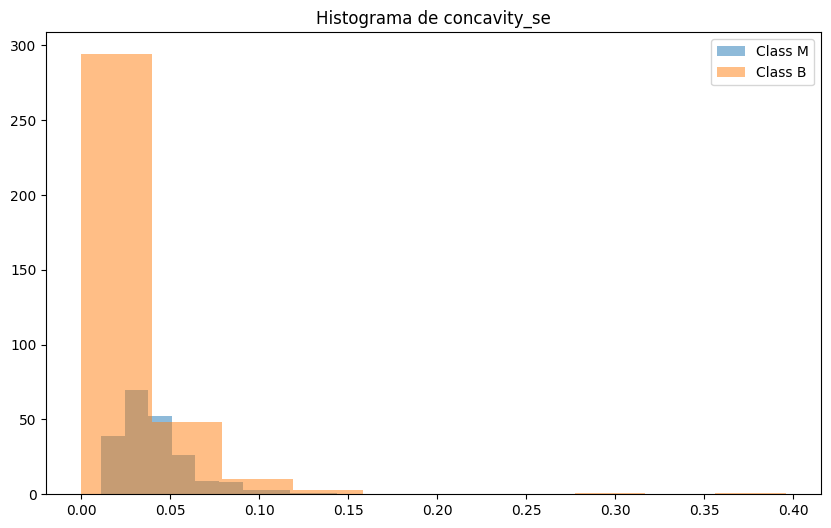

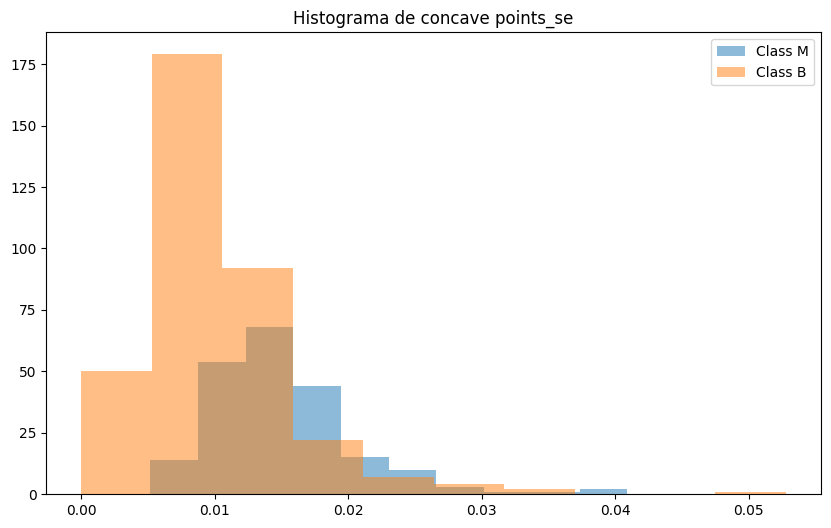

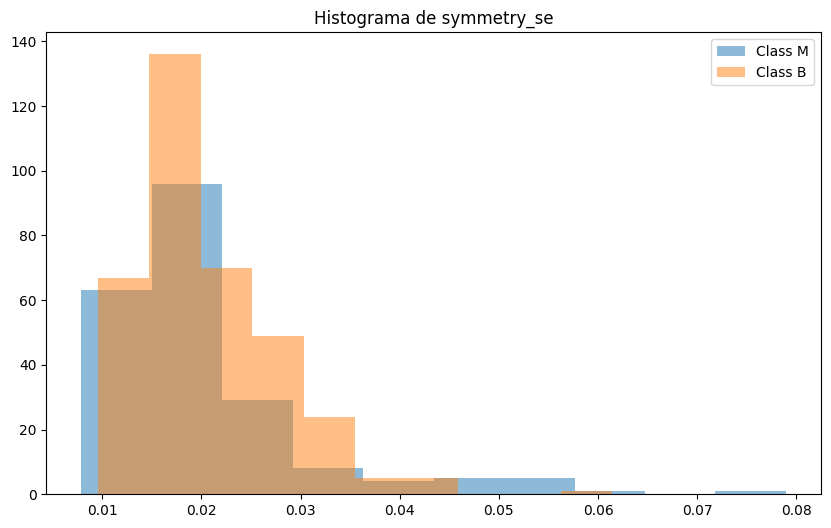

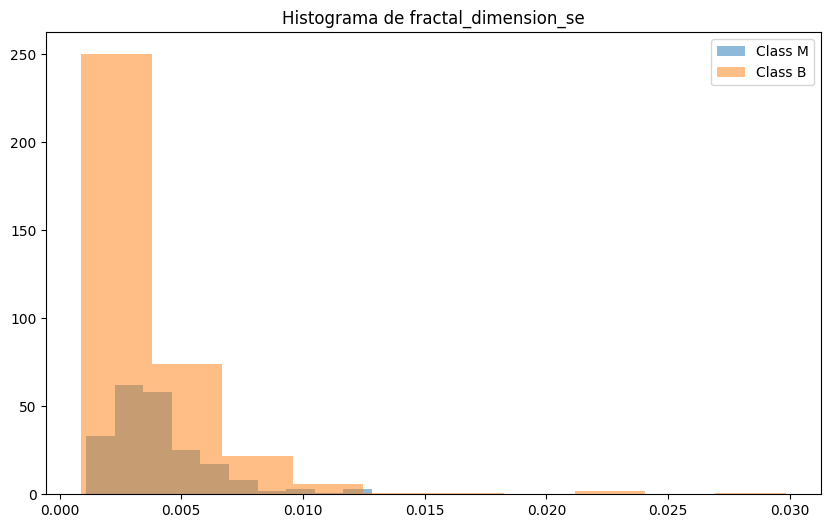

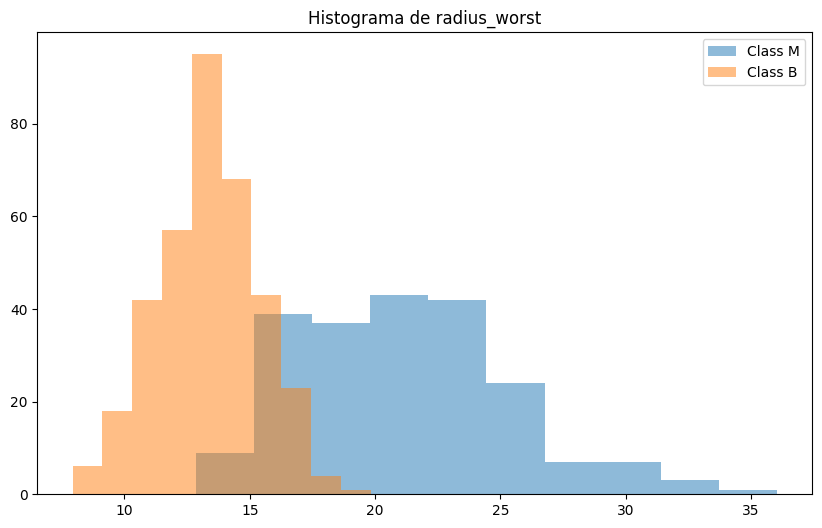

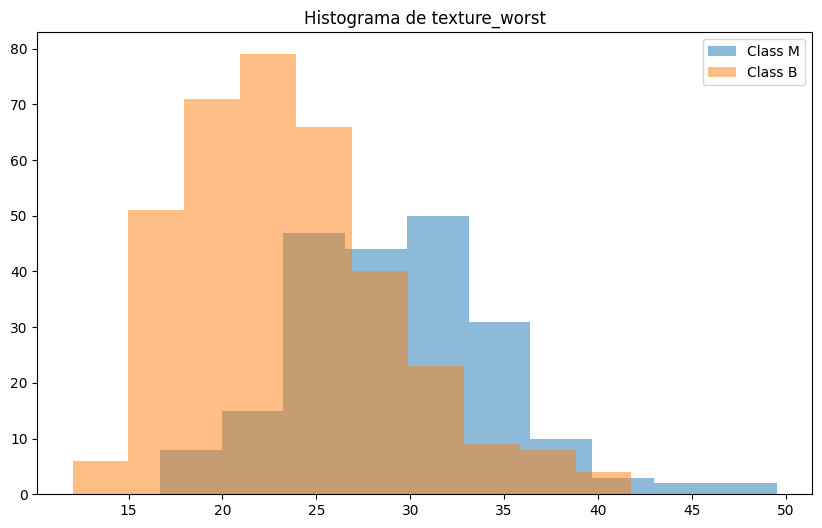

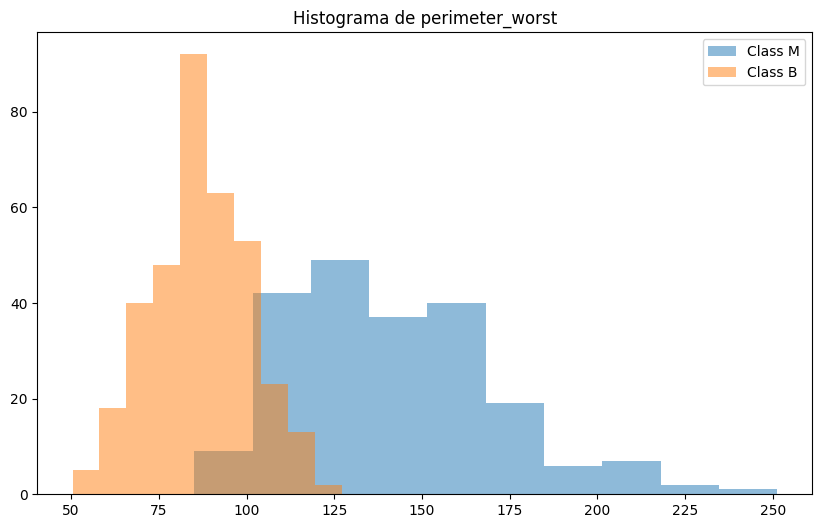

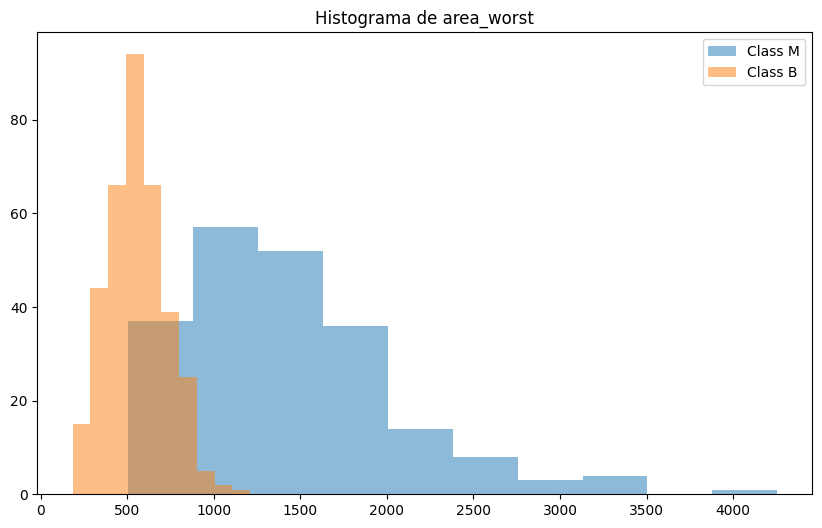

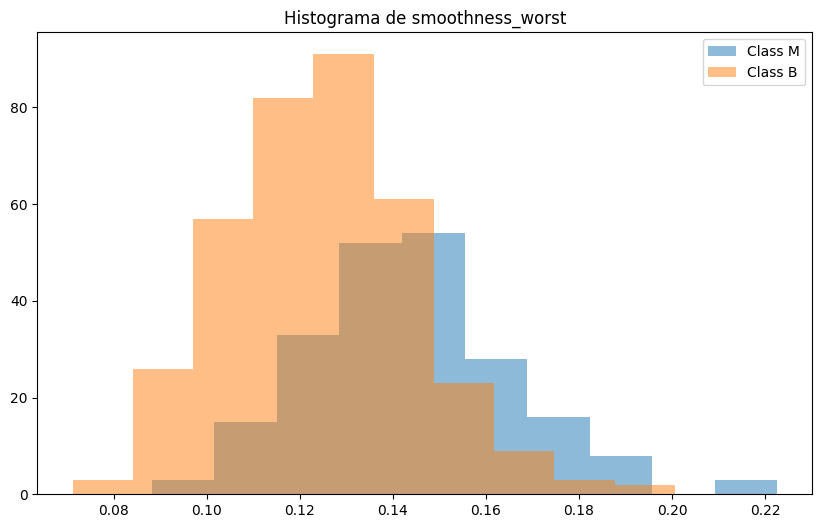

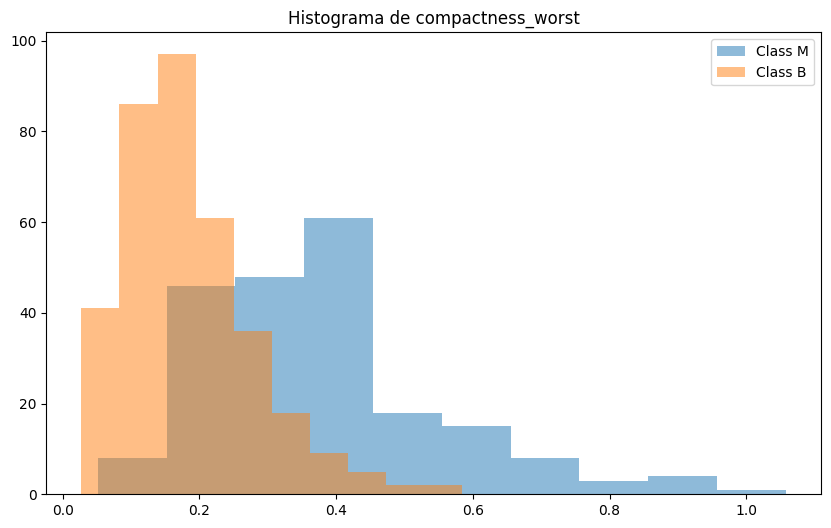

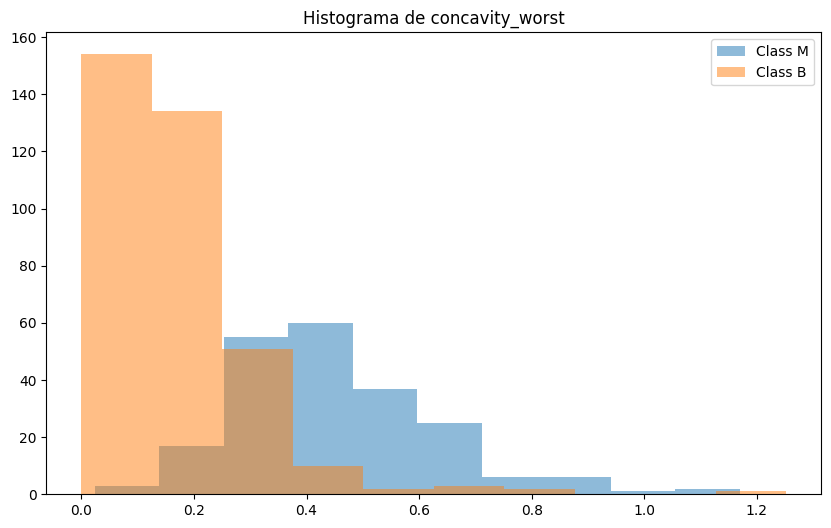

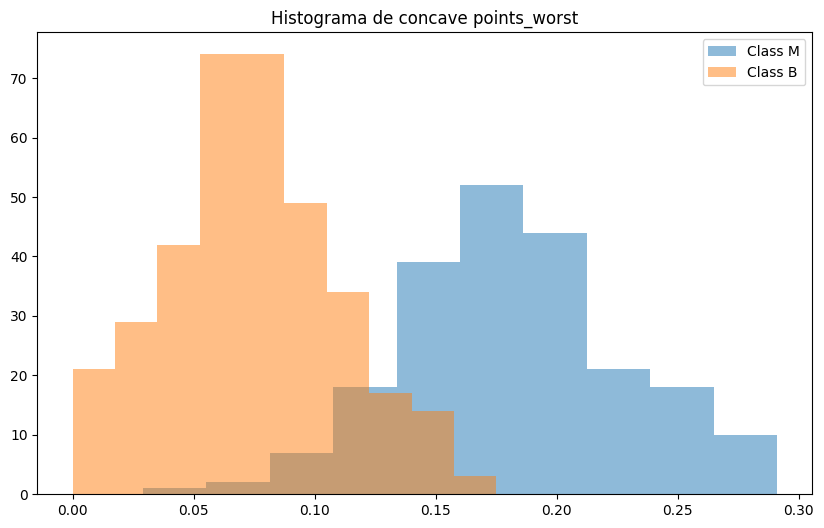

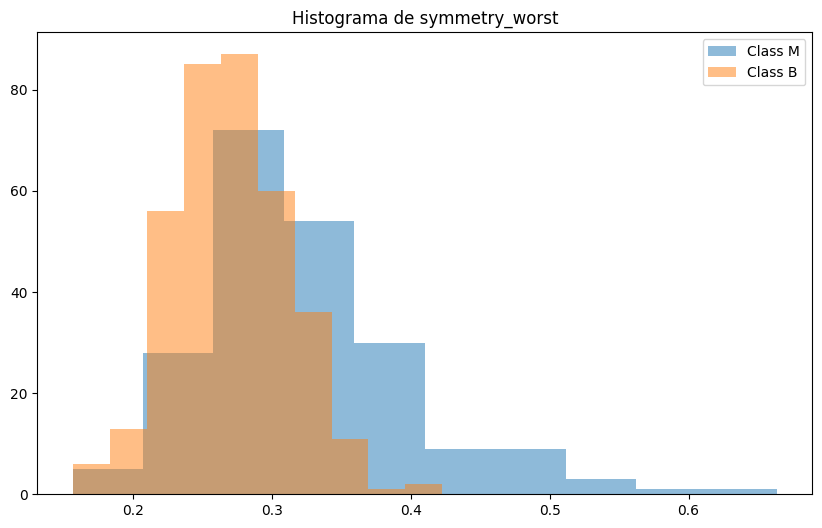

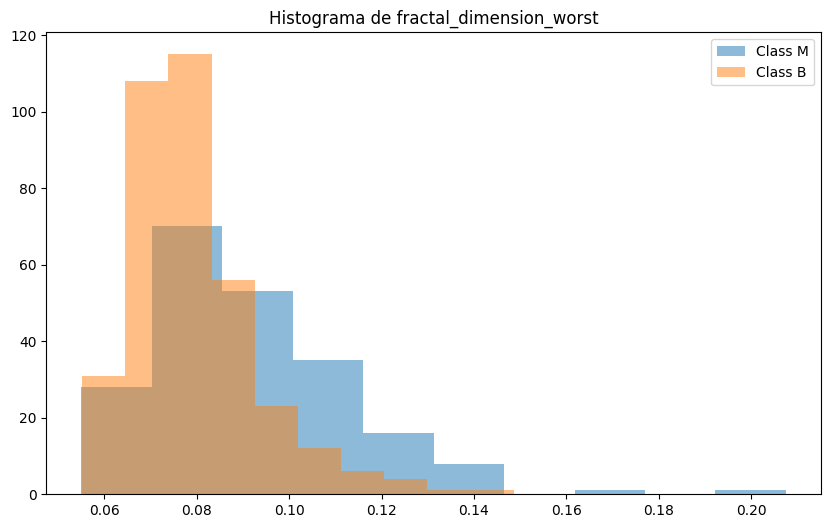

In [10]:
import matplotlib.pyplot as plt

numeric_cols = diagnostic.select_dtypes(include=['float64', 'int64']).columns
# Clases (M, B)
classes = diagnostic['diagnosis'].unique()

for feature in numeric_cols:
    plt.figure(figsize=(10, 6))
    for cls in classes:
        data = diagnostic[diagnostic['diagnosis'] == cls][feature].dropna()

        # Evitar columnas sin datos
        if data.empty:
            continue

        plt.hist(data, bins=10, alpha=0.5, label=f'Class {cls}')

    plt.title(f'Histograma de {feature}')
    plt.legend()
    plt.show()


Realizando los (4) primeros pasos:
Estandarizar los datos.
Construir la matriz de covarianza.
Obtener los autovalores y los autovectores de la matriz de covarianza.
Ordenar los autovalores por orden decreciente para clasificar los autovectores

In [11]:

#Convertir diagnosis a números ANTES del split
diagnostic['diagnosis'] = diagnostic['diagnosis'].map({'M': 1, 'B': 0})
# Division de testeo y prueba

from sklearn.model_selection import train_test_split

X, y = diagnostic.iloc[:, 1:].values, diagnostic.iloc[:, 0].values

X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.3,
                     stratify=y,
                     random_state=0)

In [12]:
#1 Estandandarizacion de los datos

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)




In [13]:
import numpy as np

# Calcular el promedio de cada columna
promedio_columnas = np.mean(X_train_std, axis=0)
print(promedio_columnas)

[-1.31162529e-15 -1.03846301e-15  9.34902630e-16  6.71015449e-16
 -5.34748125e-15 -2.80728818e-15  2.36968457e-16  3.93599168e-16
 -1.93411425e-15  5.54497821e-15  2.35155279e-16  5.35654714e-16
  1.09794920e-15 -1.13114431e-16 -9.96411217e-16  6.86218251e-16
  1.30513969e-16 -1.19906876e-15 -1.59643376e-15 -6.89007756e-17
 -3.17124886e-15  3.63291195e-15  6.75199706e-16  4.61523617e-16
 -2.74710461e-15 -6.75496091e-16  7.86640435e-16  5.96396188e-16
  2.96608076e-15 -2.00272518e-15]


In [14]:
m_prom = np.full_like(X_train_std, promedio_columnas, dtype=float)
n_m = X_train_std - m_prom
n_m_Trans = n_m.T
Res_multi = n_m_Trans @ n_m #Producto punto

filas, columnas = X_train_std.shape

S = Res_multi / (filas-1)

# Establecer opciones de impresión para mostrar toda la matriz en una línea
np.set_printoptions(threshold=np.inf, linewidth=np.inf)

# Calcular la matriz de covarianza
cov_matrix = np.cov(X_train_std, rowvar=False)  # rowvar=False indica que las variables están en columnas
#cov_mat = np.cov(X_train_std.T)

print(cov_matrix)

[[ 1.00251889  0.30056303  1.00030723  0.98848731  0.23607204  0.5552457   0.71976514  0.84234758  0.16249033 -0.26493022  0.68028888 -0.05528574  0.67773511  0.72610393 -0.17096091  0.27205517  0.27834919  0.44226065 -0.03456438 -0.01418335  0.97124304  0.27068436  0.96497862  0.9471502   0.13344013  0.43918094  0.54039123  0.74937348  0.17164784  0.01756902]
 [ 0.30056303  1.00251889  0.30738783  0.29028079  0.00495174  0.24690335  0.30856088  0.29111861  0.08804995 -0.0528066   0.25142688  0.41532859  0.25879575  0.2234854   0.04053317  0.20839086  0.18516917  0.19746603  0.0282482   0.08505953  0.31946714  0.91438815  0.32684903  0.30061462  0.0866527   0.27585201  0.3008462   0.28738503  0.09289202  0.13290791]
 [ 1.00030723  0.30738783  1.00251889  0.98786201  0.27252233  0.60561226  0.75806304  0.86954785  0.19902658 -0.21241591  0.69309315 -0.04294212  0.69643856  0.73629767 -0.15197813  0.31807846  0.31489661  0.47117831 -0.00998641  0.0246161   0.97238733  0.2793249   0.97149

3. Se procede a calcular los eigenvalores y eigenvectores a la matriz de covarianza:

Los autovectores de la matriz de covarianza representan los componentes principales (las direcciones de la varianza maxima)

Los autovalores definen la magnitud.

In [15]:
eigen_vals, eigen_vecs = np.linalg.eig(cov_matrix)

print('\nEigenvalues \n%s' % eigen_vals)


Eigenvalues 
[1.36731186e+01 5.24345457e+00 2.98616822e+00 2.02781347e+00 1.59457182e+00 1.20052371e+00 7.18206198e-01 4.83717557e-01 4.49825008e-01 3.24270826e-01 2.87328307e-01 2.50375271e-01 1.97704091e-01 1.43198405e-01 9.33618371e-02 8.45979209e-02 6.22979471e-02 6.00167889e-02 4.56439623e-02 1.09941257e-04 6.70242896e-04 1.63473205e-03 6.26610286e-03 7.71736076e-03 1.10145205e-02 1.67655323e-02 2.14864577e-02 2.61530744e-02 2.90734572e-02 2.84808465e-02]


4. Ordenar los autovalores por orden decreciente para clasificar los autovectores.

In [16]:
tot = sum(eigen_vals)

var_exp = [(i / tot) for i in sorted(eigen_vals, reverse=True)]

print(var_exp)

[np.float64(0.454625466858082), np.float64(0.17434266856724015), np.float64(0.09928884276080599), np.float64(0.06742394881708677), np.float64(0.05301884528006369), np.float64(0.039916910661850415), np.float64(0.023880055311414017), np.float64(0.016083406193689552), np.float64(0.014956493155697142), np.float64(0.010781869167961054), np.float64(0.009553545874968596), np.float64(0.008324872912524647), np.float64(0.006573578236524557), np.float64(0.004761287009227484), np.float64(0.0031042419888353025), np.float64(0.0028128454428302248), np.float64(0.002071380653305935), np.float64(0.001995533097949833), np.float64(0.001517642632942781), np.float64(0.0009666802787309919), np.float64(0.0009469762210987379), np.float64(0.0008695787729965493), np.float64(0.0007144157212613034), np.float64(0.0005574469272690174), np.float64(0.0003662281936468716), np.float64(0.0002565990134305472), np.float64(0.00020834529608404012), np.float64(5.435415611238386e-05), np.float64(2.228529561035777e-05), np.floa

In [17]:
cum_var_exp = np.cumsum(var_exp)

print(cum_var_exp)

[0.45462547 0.62896814 0.72825698 0.79568093 0.84869977 0.88861668 0.91249674 0.92858014 0.94353664 0.95431851 0.96387205 0.97219693 0.9787705  0.98353179 0.98663603 0.98944888 0.99152026 0.99351579 0.99503343 0.99600011 0.99694709 0.99781667 0.99853109 0.99908853 0.99945476 0.99971136 0.99991971 0.99997406 0.99999634 1.        ]


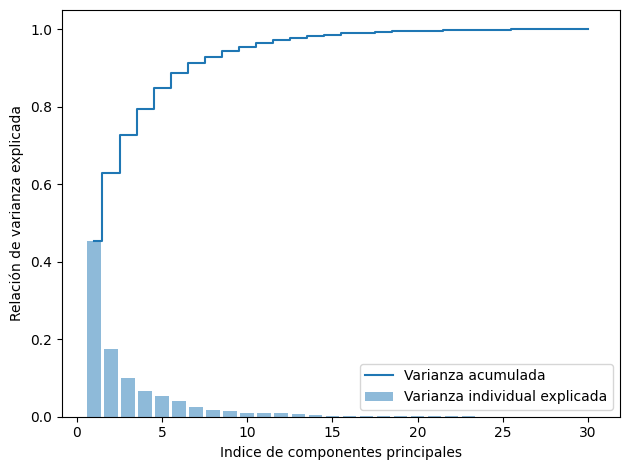

In [18]:
import matplotlib.pyplot as plt

n = len(var_exp)

plt.bar(range(1, n + 1), var_exp, alpha=0.5, align='center',
        label='Varianza individual explicada')
plt.step(range(1, n + 1), cum_var_exp, where='mid',
         label='Varianza acumulada')
plt.ylabel('Relación de varianza explicada')
plt.xlabel('Indice de componentes principales')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


5.   Seleccionar k autovectores que correspondan a los k autovalores mayores, donde k es la dimensionalidad del nuevo subespacio de características (k<=d)
6.   Construir una matriz de proyección **W** a partir de los **k **autovectores.
7.   Transformar el conjunto de datos de entrada **X** de **d** dimensiones para obtener el nuevo subespacio de características de **k** dimensiones.

5. Seleccionar k autovectores que correspondan a los k autovalores mayores, donde k es la dimensionalidad del nuevo subespacio de características (k<=d)

In [19]:
# Hacer una lista de las tuplas (autovalor, autovector):

eigen_pairs = [(np.abs(eigen_vals[i]), eigen_vecs[:, i])
               for i in range(len(eigen_vals))]

print(eigen_pairs)

# Ordenar las tuplas (autovalor, autovector) de mayor a menor
eigen_pairs.sort(key=lambda k: k[0], reverse=True)

[(np.float64(13.673118575026457), array([0.21879843, 0.09818746, 0.2274425 , 0.22082837, 0.15503953, 0.24141471, 0.25864725, 0.25896496, 0.13379101, 0.07151835, 0.2001303 , 0.02738134, 0.20586003, 0.19777132, 0.02241951, 0.17819002, 0.16727064, 0.1866018 , 0.05286232, 0.09959407, 0.22834115, 0.09996262, 0.23656006, 0.22717279, 0.12967832, 0.20885304, 0.22602566, 0.24654765, 0.11982791, 0.12754261])), (np.float64(5.2434545659769505), array([ 0.23764319,  0.03904195,  0.2173187 ,  0.23501692, -0.1855439 , -0.14423022, -0.04571397,  0.0422654 , -0.19311174, -0.37752757,  0.1200457 , -0.08950311,  0.10323214,  0.15868211, -0.19403372, -0.22640581, -0.18245491, -0.09922225, -0.1617829 , -0.28030992,  0.21797088,  0.01627472,  0.19668063,  0.21598958, -0.18758475, -0.14655328, -0.10233925,  0.00702059, -0.14733328, -0.28906875])), (np.float64(2.986168218045402), array([-0.01169351,  0.04918321, -0.01128261,  0.02610199, -0.05271157, -0.06286546, -0.0087495 , -0.0227727 , -0.02080082, -0.0057

In [20]:
w = np.hstack((eigen_pairs[0][1][:, np.newaxis],
               eigen_pairs[1][1][:, np.newaxis]))
print('Matriz W:\n', w)

Matriz W:
 [[ 0.21879843  0.23764319]
 [ 0.09818746  0.03904195]
 [ 0.2274425   0.2173187 ]
 [ 0.22082837  0.23501692]
 [ 0.15503953 -0.1855439 ]
 [ 0.24141471 -0.14423022]
 [ 0.25864725 -0.04571397]
 [ 0.25896496  0.0422654 ]
 [ 0.13379101 -0.19311174]
 [ 0.07151835 -0.37752757]
 [ 0.2001303   0.1200457 ]
 [ 0.02738134 -0.08950311]
 [ 0.20586003  0.10323214]
 [ 0.19777132  0.15868211]
 [ 0.02241951 -0.19403372]
 [ 0.17819002 -0.22640581]
 [ 0.16727064 -0.18245491]
 [ 0.1866018  -0.09922225]
 [ 0.05286232 -0.1617829 ]
 [ 0.09959407 -0.28030992]
 [ 0.22834115  0.21797088]
 [ 0.09996262  0.01627472]
 [ 0.23656006  0.19668063]
 [ 0.22717279  0.21598958]
 [ 0.12967832 -0.18758475]
 [ 0.20885304 -0.14655328]
 [ 0.22602566 -0.10233925]
 [ 0.24654765  0.00702059]
 [ 0.11982791 -0.14733328]
 [ 0.12754261 -0.28906875]]


In [21]:
X_train_std[0]

array([-0.35062921,  0.03857312, -0.37539381, -0.4071762 , -0.34380059, -0.45156593, -0.85647945, -0.68845764,  0.19848424,  0.11362249, -0.13694527, -0.82060105, -0.13351625, -0.28990165, -0.34891424, -0.65437429, -0.87691688, -0.82873045,  0.23169284, -0.53592958, -0.3735545 , -0.22497479, -0.35631643, -0.44486368, -0.46528942, -0.54626061, -0.93382645, -0.73704916,  0.68771639, -0.3562927 ])

In [22]:
X_train_std[0].dot(w)

array([-2.2006342 ,  0.37485042])

7. Transformar el conjunto de datos de entrada X de d dimensiones para obtener el nuevo subespacio de características de k dimensiones.

In [23]:
X_train_pca = X_train_std.dot(w)

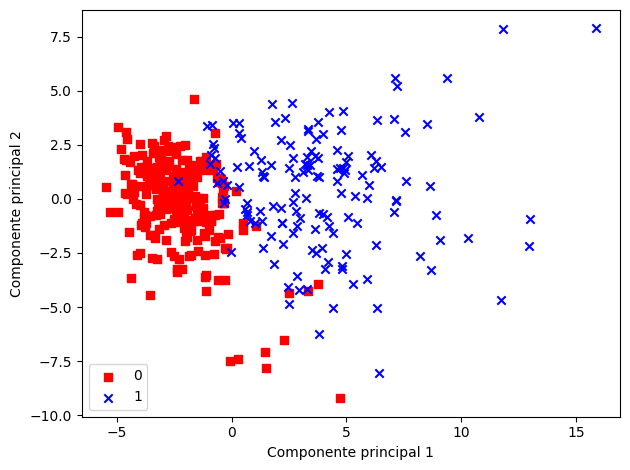

In [24]:
colors = ['r', 'b', 'g']
markers = ['s', 'x', 'o']

for l, c, m in zip(np.unique(y_train), colors, markers):
    plt.scatter(X_train_pca[y_train == l, 0],
                X_train_pca[y_train == l, 1],
                c=c, label=l, marker=m)

plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

Función para la graficación de la superfice de separación:

In [25]:
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class samples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.6,
                    c=cmap(idx),
                    edgecolor='black',
                    marker=markers[idx],
                    label=cl)

#**MODELO 2 CON 3 COMPONENTES: SVM**

#PCA

Validar la relación de varianza explicada de todos los componentes principales:

In [26]:
from sklearn.decomposition import PCA

pca1 = PCA()

X_train_pca = pca1.fit_transform(X_train_std)

pca1.explained_variance_ratio_

array([4.54625467e-01, 1.74342669e-01, 9.92888428e-02, 6.74239488e-02, 5.30188453e-02, 3.99169107e-02, 2.38800553e-02, 1.60834062e-02, 1.49564932e-02, 1.07818692e-02, 9.55354587e-03, 8.32487291e-03, 6.57357824e-03, 4.76128701e-03, 3.10424199e-03, 2.81284544e-03, 2.07138065e-03, 1.99553310e-03, 1.51764263e-03, 9.66680279e-04, 9.46976221e-04, 8.69578773e-04, 7.14415721e-04, 5.57446927e-04, 3.66228194e-04, 2.56599013e-04, 2.08345296e-04, 5.43541561e-05, 2.22852956e-05, 3.65550076e-06])

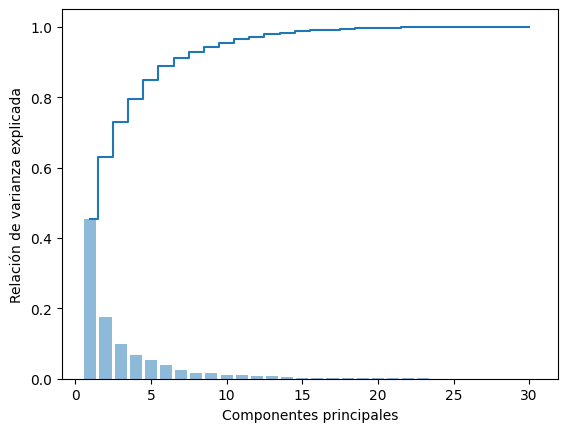

In [27]:

n = len(pca1.explained_variance_ratio_)

plt.bar(range(1, n + 1), pca1.explained_variance_ratio_, alpha=0.5, align='center')
plt.step(range(1, n +1), np.cumsum(pca1.explained_variance_ratio_), where='mid')
plt.ylabel('Relación de varianza explicada')
plt.xlabel('Componentes principales')

plt.show()

In [34]:
pca1 = PCA(n_components=3)

X_train_pca = pca1.fit_transform(X_train_std)

X_test_pca = pca1.transform(X_test_std)

In [35]:
# Para obtener la matriz de proyección W
W = pca1.components_
print(W)

[[ 0.21879843  0.09818746  0.2274425   0.22082837  0.15503953  0.24141471  0.25864725  0.25896496  0.13379101  0.07151835  0.2001303   0.02738134  0.20586003  0.19777132  0.02241951  0.17819002  0.16727064  0.1866018   0.05286232  0.09959407  0.22834115  0.09996262  0.23656006  0.22717279  0.12967832  0.20885304  0.22602566  0.24654765  0.11982791  0.12754261]
 [-0.23764319 -0.03904195 -0.2173187  -0.23501692  0.1855439   0.14423022  0.04571397 -0.0422654   0.19311174  0.37752757 -0.1200457   0.08950311 -0.10323214 -0.15868211  0.19403372  0.22640581  0.18245491  0.09922225  0.1617829   0.28030992 -0.21797088 -0.01627472 -0.19668063 -0.21598958  0.18758475  0.14655328  0.10233925 -0.00702059  0.14733328  0.28906875]
 [-0.01169351  0.04918321 -0.01128261  0.02610199 -0.05271157 -0.06286546 -0.0087495  -0.0227727  -0.02080082 -0.00572154  0.26380242  0.36868235  0.26514235  0.21577685  0.33998192  0.1527305   0.14709325  0.21025196  0.31475775  0.21638477 -0.06078897 -0.06433454 -0.05965

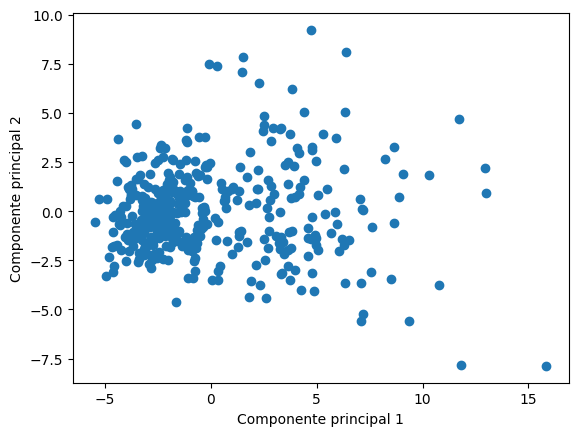

In [36]:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1])
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.show()

#SVM

In [37]:

from sklearn.svm import SVC

svm = SVC(kernel='linear', C=0.1, random_state=1, probability=True)
svm.fit(X_train_pca, y_train)

SVC(C=0.1, kernel='linear', probability=True, random_state=1)

In [38]:
X.var()


np.float64(52119.70516752481)

TRAIN

In [39]:
import plotly.graph_objects as go
import pandas as pd

# Construir DataFrame para facilitar el manejo
df_plot = pd.DataFrame({
    'PC1': X_train_pca[:, 0],
    'PC2': X_train_pca[:, 1],
    'PC3': X_train_pca[:, 2],
    'diagnosis': y_train
})

fig = go.Figure(data=[go.Scatter3d(
    x=df_plot['PC1'],
    y=df_plot['PC2'],
    z=df_plot['PC3'],
    mode='markers',
    marker=dict(
        size=6,
        color=df_plot['diagnosis'],   # colores según clase
        colorscale='Viridis',
        opacity=0.8
    )
)])

fig.update_layout(
    title='PCA en 3 Componentes (Interactivo)',
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    width=800,
    height=700
)

fig.show()

TEST

In [40]:
import plotly.graph_objects as go
import pandas as pd

# Construir DataFrame para el SET DE TEST
df_plot_test = pd.DataFrame({
    'PC1': X_test_pca[:, 0],
    'PC2': X_test_pca[:, 1],
    'PC3': X_test_pca[:, 2],
    'diagnosis': y_test    # ← NO usar .values
})

fig = go.Figure(data=[go.Scatter3d(
    x=df_plot_test['PC1'],
    y=df_plot_test['PC2'],
    z=df_plot_test['PC3'],
    mode='markers',
    marker=dict(
        size=6,
        color=df_plot_test['diagnosis'],   # clase 0/1
        colorscale='Viridis',
        opacity=0.85
    )
)])

fig.update_layout(
    title='PCA en 3 Componentes (SET DE TEST — Interactivo)',
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    width=800,
    height=700
)

fig.show()


In [42]:
print(diagnostic.iloc[0])

diagnosis                     1.000000
radius_mean                  17.990000
texture_mean                 10.380000
perimeter_mean              122.800000
area_mean                  1001.000000
smoothness_mean               0.118400
compactness_mean              0.277600
concavity_mean                0.300100
concave points_mean           0.147100
symmetry_mean                 0.241900
fractal_dimension_mean        0.078710
radius_se                     1.095000
texture_se                    0.905300
perimeter_se                  8.589000
area_se                     153.400000
smoothness_se                 0.006399
compactness_se                0.049040
concavity_se                  0.053730
concave points_se             0.015870
symmetry_se                   0.030030
fractal_dimension_se          0.006193
radius_worst                 25.380000
texture_worst                17.330000
perimeter_worst             184.600000
area_worst                 2019.000000
smoothness_worst         

#Matriz de confusion

In [44]:

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Obtener las probabilidades de predicción para las primeras 3 muestras del conjunto de prueba

y_train_pred = svm.predict(X_train_pca)
y_test_pred = svm.predict(X_test_pca)


# Matrices de confusión
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

print('Matriz de confusión - TRAIN (SVM lineal):')
print(cm_train)
print('\nMatriz de confusión - TEST (SVM lineal):')
print(cm_test)

Matriz de confusión - TRAIN (SVM lineal):
[[246   4]
 [ 11 137]]

Matriz de confusión - TEST (SVM lineal):
[[98  9]
 [ 5 59]]


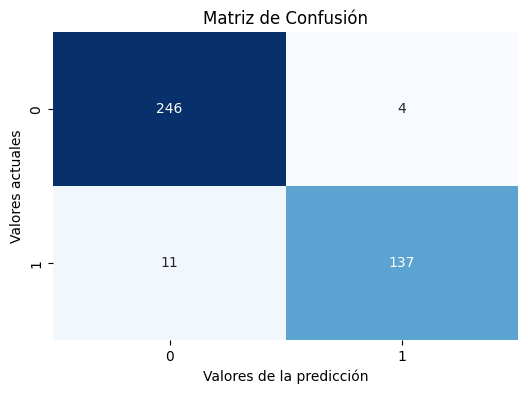

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Graficar la matriz de confusión train
plt.figure(figsize=(6, 4))
sns.heatmap(cm_train, annot=True, cmap='Blues', fmt='g', cbar=False)
plt.xlabel('Valores de la predicción')
plt.ylabel('Valores actuales')
plt.title('Matriz de Confusión')
plt.show()

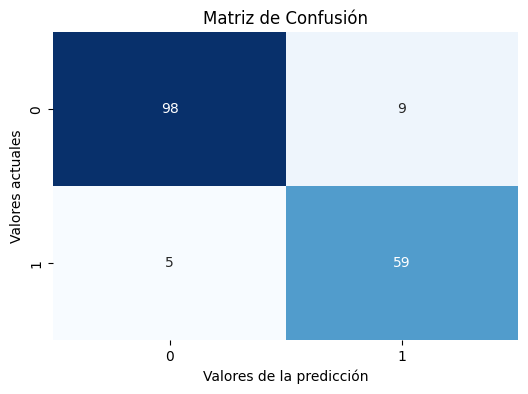

In [46]:
# Graficar la matriz de confusión test
plt.figure(figsize=(6, 4))
sns.heatmap(cm_test, annot=True, cmap='Blues', fmt='g', cbar=False)
plt.xlabel('Valores de la predicción')
plt.ylabel('Valores actuales')
plt.title('Matriz de Confusión')
plt.show()

In [47]:
#-- Calcular todas las métricas explicadas en el aula de clase que se pueden obtener a partir de
#-- los resultados obtenidos en el ítem 5.5.

class metricas_matriz_confusion(object):

  #
    def __init__(self, cm):
        self.TP = cm[1][1]
        self.FP = cm[0][1]
        self.FN = cm[1][0]
        self.TN = cm[0][0]

        self.accuracy = (self.TP+self.TN)/(self.TP+self.FP+self.FN+self.TN)
        self.error_rate = (self.FP+self.FN)/(self.TP+self.FP+self.FN+self.TN)
        self.precision = (self.TP)/(self.TP+self.FP)
        self.recall = (self.TP)/(self.TP+self.FN)
        self.especificity = (self.TN)/(self.TN+self.FP)




In [48]:
#Test

#Calcular las metricas de la matriz de confusion
metrics_ppn_1 =metricas_matriz_confusion(cm_test)


print("El valor de exactitud (accuracy) es: " + str(metrics_ppn_1.accuracy))
print("El valor de tasa de error (error_rate) es: " + str(metrics_ppn_1.error_rate))
print("El valor de precisión (precision) es: " + str(metrics_ppn_1.precision))
print("El valor de recall (sensibilidad / sensitivity / true positive rate) es: " + str(metrics_ppn_1.recall))
print("El valor de especificidad (especificity) es: " + str(metrics_ppn_1.especificity))

El valor de exactitud (accuracy) es: 0.9181286549707602
El valor de tasa de error (error_rate) es: 0.08187134502923976
El valor de precisión (precision) es: 0.8676470588235294
El valor de recall (sensibilidad / sensitivity / true positive rate) es: 0.921875
El valor de especificidad (especificity) es: 0.9158878504672897


In [49]:
#Train
metrics_ppn_2 =metricas_matriz_confusion(cm_train)

print("El valor de exactitud (accuracy) es: " + str(metrics_ppn_2.accuracy))
print("El valor de tasa de error (error_rate) es: " + str(metrics_ppn_2.error_rate))
print("El valor de precisión (precision) es: " + str(metrics_ppn_2.precision))
print("El valor de recall (sensibilidad / sensitivity / true positive rate) es: " + str(metrics_ppn_2.recall))
print("El valor de especificidad (especificity) es: " + str(metrics_ppn_2.especificity))

El valor de exactitud (accuracy) es: 0.9623115577889447
El valor de tasa de error (error_rate) es: 0.03768844221105527
El valor de precisión (precision) es: 0.9716312056737588
El valor de recall (sensibilidad / sensitivity / true positive rate) es: 0.9256756756756757
El valor de especificidad (especificity) es: 0.984


#CURVA DE ROC

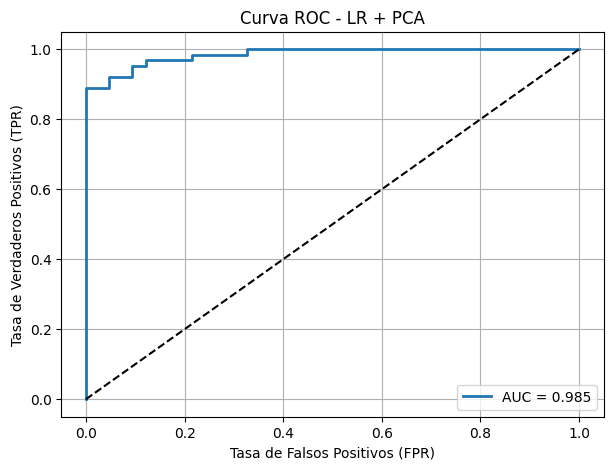

In [51]:
from sklearn.metrics import roc_curve, auc

# 1. Probabilidades usando PCA
y_prob = svm.predict_proba(X_test_pca)[:, 1]

# 2. ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# 3. Plot ROC
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}', linewidth=2)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - LR + PCA')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


#Prueba :
Se procede a generar un dato muy parecido, que pertenezca a la clase 1:

In [52]:
dato_Nuevo = np.array([
    12.3, 14.5, 78.0, 450.0, 0.09, 0.12, 0.05, 0.03, 0.18, 0.06,
    0.7, 1.0, 5.0, 20.0, 0.01, 0.04, 0.02, 0.01, 0.1, 0.03,
    14.0, 18.0, 90.0, 500.0, 0.12, 0.20, 0.10, 0.07, 0.24, 0.08
])

dato_Nuevo = dato_Nuevo.reshape(1, -1)

nuevo_dato_std = sc.transform(dato_Nuevo)

nuevo_dato_pca = np.dot(nuevo_dato_std, W.T)



In [54]:
Res_prediccion_= svm.predict(nuevo_dato_pca)
print(Res_prediccion_)

[0]
